In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from src.data_loader import get_con

con = get_con()
print("Connected to DuckDB")

Connected to DuckDB


In [2]:
delivery = con.execute("""
    SELECT
        o.order_id,
        c.customer_state,
        s.seller_state,
        DATEDIFF('day',
            o.order_purchase_timestamp::DATE,
            o.order_delivered_customer_date::DATE)      AS actual_delivery_days,
        DATEDIFF('day',
            o.order_purchase_timestamp::DATE,
            o.order_estimated_delivery_date::DATE)      AS estimated_delivery_days,
        DATEDIFF('day',
            o.order_delivered_customer_date::DATE,
            o.order_estimated_delivery_date::DATE)      AS days_early,
        CASE WHEN o.order_delivered_customer_date::DATE
                  <= o.order_estimated_delivery_date::DATE
             THEN 1 ELSE 0 END                          AS on_time,
        i.freight_value,
        i.price,
        r.review_score,
        DATE_TRUNC('month',
            o.order_purchase_timestamp::TIMESTAMP)::DATE AS month
    FROM orders o
    JOIN customers c    USING (customer_id)
    JOIN order_items i  USING (order_id)
    JOIN sellers s      USING (seller_id)
    LEFT JOIN reviews r USING (order_id)
    WHERE o.order_status = 'delivered'
      AND o.order_delivered_customer_date IS NOT NULL
      AND o.order_estimated_delivery_date IS NOT NULL
""").df()

delivery["month"] = pd.to_datetime(delivery["month"])

print(f"Delivered orders : {len(delivery):,}")
print(f"\nDelivery stats:")
print(delivery[["actual_delivery_days","estimated_delivery_days",
                "days_early","freight_value"]].describe().round(2))

Delivered orders : 110,832

Delivery stats:
       actual_delivery_days  estimated_delivery_days  days_early  \
count             110832.00                110832.00   110832.00   
mean                  12.42                    24.45       12.03   
std                    9.45                     8.82       10.16   
min                    0.00                     3.00     -188.00   
25%                    7.00                    19.00        7.00   
50%                   10.00                    24.00       13.00   
75%                   16.00                    29.00       17.00   
max                  210.00                   156.00      147.00   

       freight_value  
count      110832.00  
mean           19.94  
std            15.67  
min             0.00  
25%            13.08  
50%            16.25  
75%            21.15  
max           409.68  


In [3]:
total = len(delivery)
on_time_rate = delivery["on_time"].mean() * 100
avg_actual   = delivery["actual_delivery_days"].mean()
avg_est      = delivery["estimated_delivery_days"].mean()
avg_early    = delivery["days_early"].mean()
avg_freight  = delivery["freight_value"].mean()

print("OVERALL LOGISTICS KPIs")
print(f"Total deliveries      : {total:,}")
print(f"On-time rate          : {on_time_rate:.1f}%")
print(f"Avg actual days       : {avg_actual:.1f} days")
print(f"Avg estimated days    : {avg_est:.1f} days")
print(f"Avg days early        : {avg_early:.1f} days")
print(f"Avg freight value     : BRL {avg_freight:.2f}")
print(f"\nKey insight: Olist delivers {avg_early:.1f} days EARLIER")
print(f"than promised on average — conservative estimates protect")
print(f"customer satisfaction.")

OVERALL LOGISTICS KPIs
Total deliveries      : 110,832
On-time rate          : 93.4%
Avg actual days       : 12.4 days
Avg estimated days    : 24.4 days
Avg days early        : 12.0 days
Avg freight value     : BRL 19.94

Key insight: Olist delivers 12.0 days EARLIER
than promised on average — conservative estimates protect
customer satisfaction.


In [4]:
state_kpis = delivery.groupby("customer_state").agg(
    deliveries        = ("order_id",            "count"),
    avg_actual_days   = ("actual_delivery_days", "mean"),
    avg_estimated     = ("estimated_delivery_days","mean"),
    avg_days_early    = ("days_early",           "mean"),
    on_time_pct       = ("on_time",              "mean"),
    avg_freight       = ("freight_value",        "mean"),
    avg_review        = ("review_score",         "mean")
).reset_index().round(2)

state_kpis["on_time_pct"] = (state_kpis["on_time_pct"] * 100).round(1)
state_kpis = state_kpis[state_kpis["deliveries"] >= 100].sort_values(
    "avg_actual_days", ascending=False
)

print("Delivery KPIs by customer state (100+ deliveries):")
print(state_kpis[["customer_state","deliveries","avg_actual_days",
                   "on_time_pct","avg_freight","avg_review"]]
      .to_string(index=False))

Delivery KPIs by customer state (100+ deliveries):
customer_state  deliveries  avg_actual_days  on_time_pct  avg_freight  avg_review
            AM         164            26.30         97.0        33.27        4.09
            AL         431            24.44         79.0        35.77        3.82
            PA        1061            23.71         89.0        35.54        3.84
            MA         805            21.53         82.0        38.43        3.77
            SE         375            21.42         84.0        36.57         3.9
            CE        1431            20.91         86.0        32.73        3.87
            PB         587            20.53         89.0        43.06        4.04
            RO         273            19.66         96.0        41.33        4.07
            PI         524            19.31         86.0        39.08        3.96
            RN         523            19.26         91.0        35.71        4.11
            BA        3703            19.21    

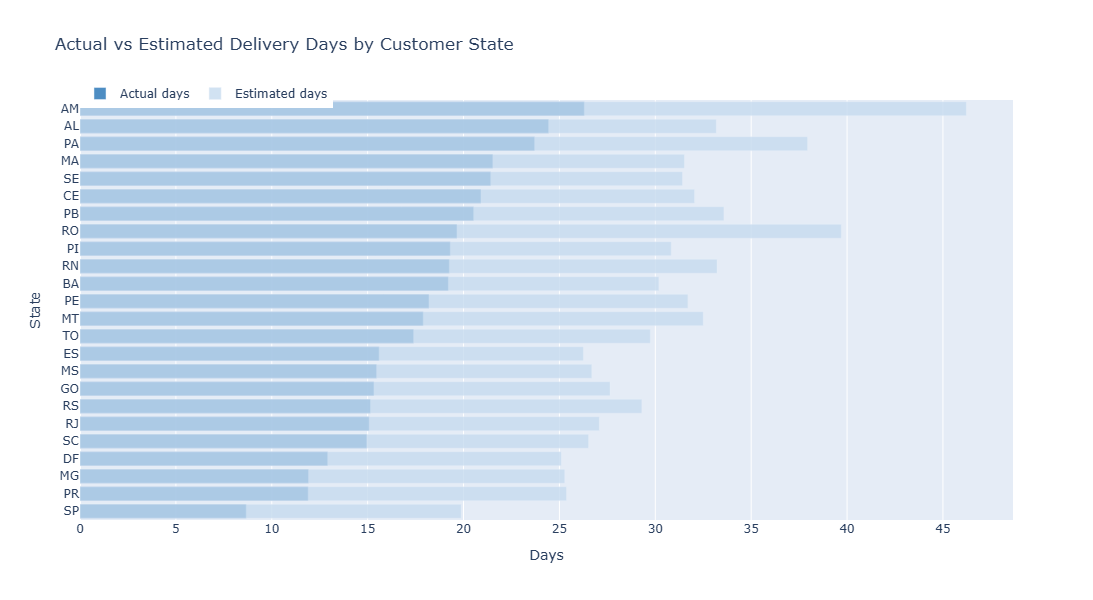

In [5]:
state_sorted = state_kpis.sort_values("avg_actual_days", ascending=True)

fig1 = go.Figure()

fig1.add_trace(go.Bar(
    x=state_sorted["avg_actual_days"],
    y=state_sorted["customer_state"],
    orientation="h",
    name="Actual days",
    marker_color="#2171b5",
    opacity=0.8
))

fig1.add_trace(go.Bar(
    x=state_sorted["avg_estimated"],
    y=state_sorted["customer_state"],
    orientation="h",
    name="Estimated days",
    marker_color="#c6dbef",
    opacity=0.8
))

fig1.update_layout(
    barmode="overlay",
    title="Actual vs Estimated Delivery Days by Customer State",
    xaxis_title="Days",
    yaxis_title="State",
    height=600,
    legend=dict(orientation="h", y=1.05)
)
fig1.show()

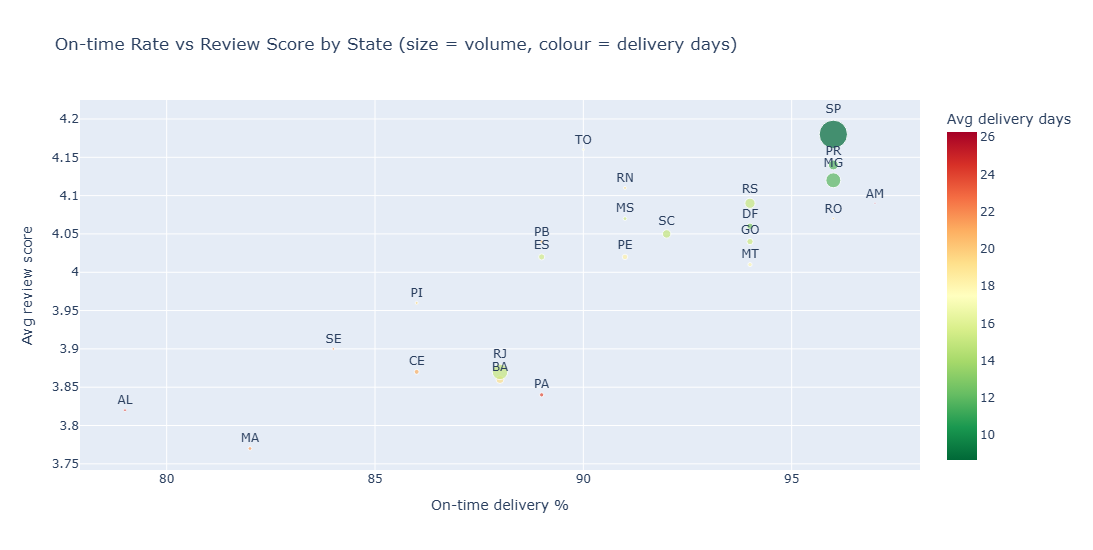

In [6]:
fig2 = px.scatter(
    state_kpis,
    x="on_time_pct",
    y="avg_review",
    size="deliveries",
    color="avg_actual_days",
    color_continuous_scale="RdYlGn_r",
    text="customer_state",
    title="On-time Rate vs Review Score by State (size = volume, colour = delivery days)",
    labels={"on_time_pct":      "On-time delivery %",
            "avg_review":       "Avg review score",
            "avg_actual_days":  "Avg delivery days"}
)
fig2.update_traces(textposition="top center")
fig2.update_layout(height=550)
fig2.show()

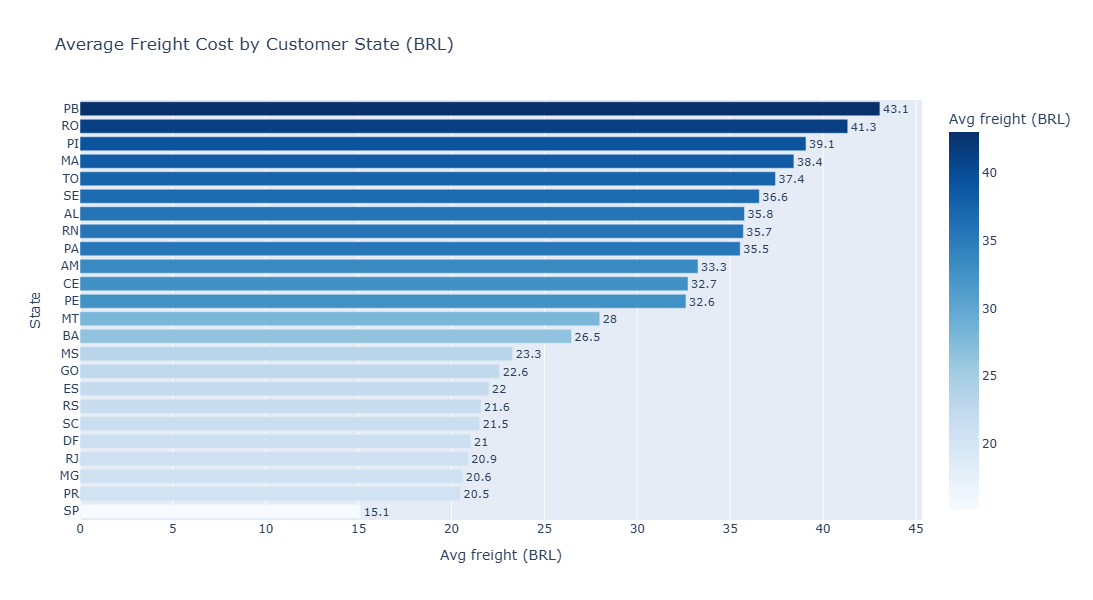

In [7]:
freight_sorted = state_kpis.sort_values("avg_freight", ascending=True)

fig3 = px.bar(
    freight_sorted,
    x="avg_freight",
    y="customer_state",
    orientation="h",
    color="avg_freight",
    color_continuous_scale="Blues",
    text=freight_sorted["avg_freight"].round(1),
    title="Average Freight Cost by Customer State (BRL)",
    labels={"avg_freight":    "Avg freight (BRL)",
            "customer_state": "State"}
)
fig3.update_traces(textposition="outside")
fig3.update_layout(height=600, showlegend=False)
fig3.show()

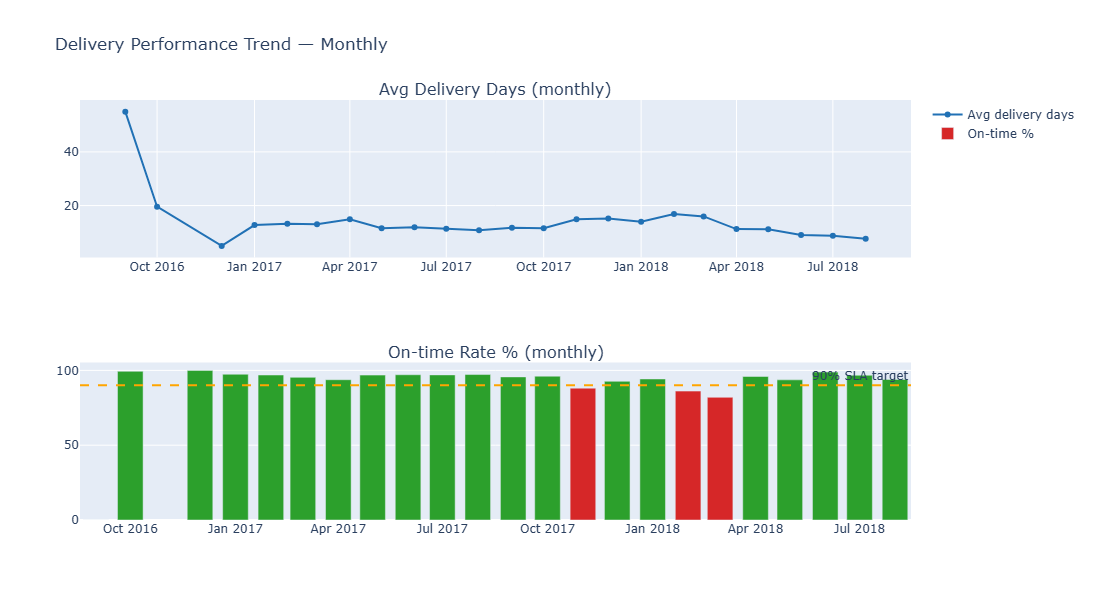

In [8]:
monthly_del = delivery.groupby("month").agg(
    deliveries      = ("order_id",            "count"),
    avg_actual_days = ("actual_delivery_days", "mean"),
    on_time_pct     = ("on_time",              "mean"),
    avg_freight     = ("freight_value",        "mean")
).reset_index()

monthly_del["on_time_pct"] = monthly_del["on_time_pct"] * 100

fig4 = make_subplots(rows=2, cols=1,
    subplot_titles=["Avg Delivery Days (monthly)",
                    "On-time Rate % (monthly)"])

fig4.add_trace(go.Scatter(
    x=monthly_del["month"],
    y=monthly_del["avg_actual_days"],
    mode="lines+markers",
    line=dict(color="#2171b5", width=2),
    name="Avg delivery days"
), row=1, col=1)

colors_ot = ["#2ca02c" if v >= 90 else "#d62728"
             for v in monthly_del["on_time_pct"]]

fig4.add_trace(go.Bar(
    x=monthly_del["month"],
    y=monthly_del["on_time_pct"],
    marker_color=colors_ot,
    name="On-time %"
), row=2, col=1)

fig4.add_hline(y=90, line_dash="dash", line_color="orange",
               row=2, col=1,
               annotation_text="90% SLA target")

fig4.update_layout(height=600,
    title="Delivery Performance Trend — Monthly")
fig4.show()

Review score by delivery status:
delivery_status  orders  avg_review
          Early  102077        4.21
           Late    7293        2.26
        On time    1462        3.98


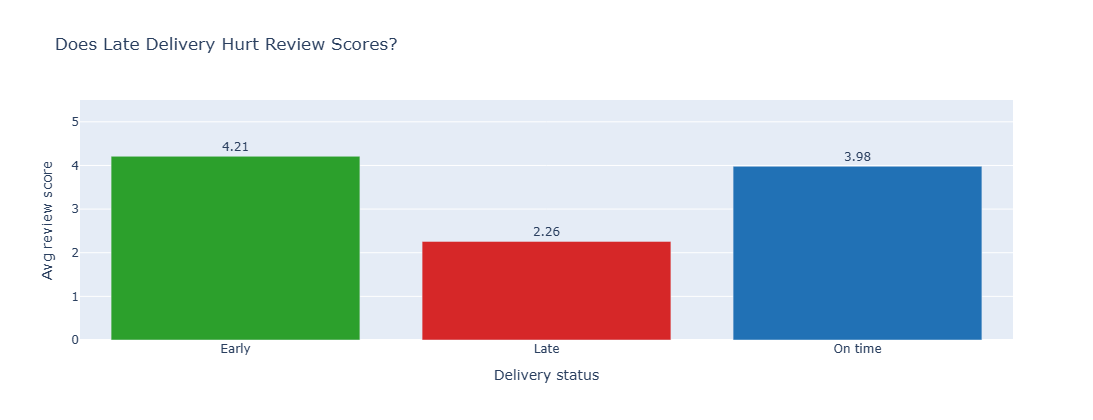

In [9]:
delivery["delivery_status"] = delivery["days_early"].apply(
    lambda x: "Early" if x > 0 else ("On time" if x == 0 else "Late")
)

review_by_status = delivery.groupby("delivery_status").agg(
    orders      = ("order_id",     "count"),
    avg_review  = ("review_score", "mean")
).reset_index().round(2)

print("Review score by delivery status:")
print(review_by_status.to_string(index=False))

fig5 = px.bar(
    review_by_status,
    x="delivery_status",
    y="avg_review",
    color="delivery_status",
    text="avg_review",
    color_discrete_map={
        "Early":   "#2ca02c",
        "On time": "#2171b5",
        "Late":    "#d62728"
    },
    title="Does Late Delivery Hurt Review Scores?",
    labels={"avg_review":      "Avg review score",
            "delivery_status": "Delivery status"}
)
fig5.update_traces(textposition="outside")
fig5.update_layout(height=420, showlegend=False,
                   yaxis=dict(range=[0, 5.5]))
fig5.show()

In [10]:
import os
os.makedirs("../docs/screenshots", exist_ok=True)

fig1.write_html("../docs/screenshots/10_delivery_by_state.html")
fig2.write_html("../docs/screenshots/10_ontime_vs_review.html")
fig3.write_html("../docs/screenshots/10_freight_by_state.html")
fig4.write_html("../docs/screenshots/10_monthly_delivery.html")
fig5.write_html("../docs/screenshots/10_review_by_delivery.html")

state_kpis.to_csv("../data/processed/10_logistics_kpis.csv", index=False)
delivery[["order_id","customer_state","actual_delivery_days",
          "on_time","freight_value","review_score"]]\
    .to_csv("../data/processed/10_delivery_detail.csv", index=False)

worst_state = state_kpis.nlargest(1,"avg_actual_days")["customer_state"].values[0]
best_state  = state_kpis.nsmallest(1,"avg_actual_days")["customer_state"].values[0]

print("DELIVERY & LOGISTICS KPIs SUMMARY")
print(f"Total deliveries     : {total:,}")
print(f"Overall on-time rate : {on_time_rate:.1f}%")
print(f"Avg actual delivery  : {avg_actual:.1f} days")
print(f"Avg estimated        : {avg_est:.1f} days")
print(f"Avg days early       : {avg_early:.1f} days")
print(f"Best state           : {best_state} ({state_kpis[state_kpis['customer_state']==best_state]['avg_actual_days'].values[0]:.1f} days)")
print(f"Worst state          : {worst_state} ({state_kpis[state_kpis['customer_state']==worst_state]['avg_actual_days'].values[0]:.1f} days)")
print()
print("FINDINGS:")
print("1. Olist delivers 12 days earlier than promised on average")
print("2. SP customers get delivery in 8.7 days vs AM at 26.3 days")
print("3. Late delivery significantly drops review scores")
print("4. Northern states have highest freight AND longest delivery")
print("5. On-time rate above 90% SLA for most states")

DELIVERY & LOGISTICS KPIs SUMMARY
Total deliveries     : 110,832
Overall on-time rate : 93.4%
Avg actual delivery  : 12.4 days
Avg estimated        : 24.4 days
Avg days early       : 12.0 days
Best state           : SP (8.7 days)
Worst state          : AM (26.3 days)

FINDINGS:
1. Olist delivers 12 days earlier than promised on average
2. SP customers get delivery in 8.7 days vs AM at 26.3 days
3. Late delivery significantly drops review scores
4. Northern states have highest freight AND longest delivery
5. On-time rate above 90% SLA for most states


In [11]:
con.close()
print("Connection closed")

Connection closed
